# Тест 3 — воспроизводит ли измеренная ошибка отклика наблюдаемый избыток

## Замысел

Тест 1 (`30_response.ipynb`) измерил, чего симуляции не хватает. Процедура была
такая: выбросить из события один хит, подогнать черенковский трек по остальным,
предсказать время прихода света на выброшенный модуль и посмотреть на разность
«наблюдено минус предсказано» — **остаток**. При согласованной геометрии реальные
остатки оказались шире симулированных, и разница соответствует примерно **29 нс**
дополнительного случайного разброса.

Это измерение сделано по одной наблюдаемой — ширине временного остатка — и доли
принятых событий не видело вовсе.

Теперь величина возвращается в симуляцию: **добавить ровно столько разброса к
временам хитов и посмотреть, сколько избытка возникнет.**

## Что именно добавляется

К временной координате **каждого хита независимо** прибавляется гауссова
случайная величина с нулевым средним и заданным `σ`:

```
t  →  t + N(0, σ)
```

Ничего больше не меняется: координаты модулей, заряды, состав событий остаются
прежними. Возмущение накладывается на **сырые** времена, до всякой фильтрации.

## Почему это не подгонка кривой

Один свободный параметр можно подкрутить под любой ответ, поэтому он не свободен.
Он **измерен заранее**, в другом тесте, по другой величине, в сравнении, где доля
принятых не участвовала. Если бы он подбирался под избыток, тест ничего бы не
стоил.

## Что переигрывается

Обе сети, с сырых хитов:

1. размытие накладывается на сырые времена;
2. заново прогоняется **sig-noise фильтр** — сеть, отделяющая свет события от
   свечения воды. Она опирается в том числе на согласованность времён, поэтому
   размытые хиты она теперь чаще принимает за шум и выбрасывает. Это настоящее
   следствие возмущения, а не побочный эффект, и его надо считать честно;
3. заново применяется отбор качества;
4. заново считается **классификатор**.

Размер батча sig-noise зафиксирован на 256: в этом конвейере он не параметр
производительности, а часть определения того, какие хиты остаются.

In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(HERE / "src"))
import present

present.glossary(["muatm", "сигнальный хит", "отбор качества", "избыток",
                  "остаток", "якорь", "ячейка", "IQR"])
DATA = HERE / "data"
scan = pd.read_parquet(DATA / "40_jitter_summary.parquet")
validation = pd.read_parquet(DATA / "41_validation.parquet")
calib = pd.read_parquet(DATA / "41_matched_calibration.parquet")
bands = pd.read_parquet(DATA / "31_by_band.parquet")
observed = float(bands[bands.band_lo == 0.8].excess_in_band.iloc[0])
BLUE, ORANGE, TEAL, INK, MUTED, SURFACE = (
    "#2a78d6", "#eb6834", "#1baf7a", "#0b0b0b", "#52514e", "#fcfcfb")
print(f"\nнаблюдаемый избыток при скоре выше 0.8: {observed:.2f}")

         muatm  —  симулированные атмосферные мюоны — фон, который мы умеем считать
сигнальный хит  —  срабатывание модуля, которому отдельная сеть sig-noise приписала вероятность
                   быть сигналом (а не шумом воды) выше 0.8
отбор качества  —  не меньше восьми сигнальных хитов не менее чем на трёх струнах (в коде это
                   условие называется h8s3, n_sn_hits ≥ 8 и n_sn_strings ≥ 3). Применяется к
                   обеим выборкам одинаково, иначе сравнивать было бы нечего
       избыток  —  во сколько раз доля экспериментальных событий в данной области скора больше
                   такой же доли у симулированных мюонов. Единица означала бы согласие
       остаток  —  разность между наблюдённым и предсказанным временем прихода света на модуль, в
                   наносекундах
         якорь  —  трек, подогнанный по остальным хитам события; по нему делается предсказание
                   для выброшенного хита
        ячейка  —  группа хитов с одинаковой гео

## Шаг 1. Скан по величине размытия

In [7]:
present.show(
    scan,
    {"sigma_ns": "добавленный разброс σ, нс",
     "n_quality": "событий прошло отбор качества",
     "n_accepted": "из них принято классификатором",
     "acceptance": "доля принятых",
     "induced_excess": "во сколько раз выросла доля принятых"},
    rows="одна величина размытия; все строки посчитаны на одних и тех же "
         "8.64 млн симулированных событий",
    source=present.artefact_note(DATA / "40_jitter_summary.parquet"),
    note="Первая строка — симуляция как есть. Последний столбец сравнивается с "
         f"наблюдаемым избытком {observed:.2f}. Второй столбец УБЫВАЕТ: чем "
         "сильнее размытие, тем больше хитов sig-noise фильтр принимает за шум, "
         "и тем меньше событий доживает до отбора качества.",
    decimals=6)
row = scan[scan.sigma_ns == 30].iloc[0]
base = scan.iloc[0]
print(f"при σ = 30 нс: принятых ×{row.n_accepted / base.n_accepted:.2f}, "
      f"прошедших отбор ×{row.n_quality / base.n_quality:.2f}")

Строка — одна величина размытия; все строки посчитаны на одних и тех же 8.64 млн симулированных событий.
Первая строка — симуляция как есть. Последний столбец сравнивается с наблюдаемым избытком 2.87.
Второй столбец УБЫВАЕТ: чем сильнее размытие, тем больше хитов sig-noise фильтр принимает за
шум, и тем меньше событий доживает до отбора качества.
Источник: стадия 40_time_jitter, файл 40_jitter_summary.parquet, 5 строк


"добавленный разброс σ, нс",событий прошло отбор качества,из них принято классификатором,доля принятых,во сколько раз выросла доля принятых
0.000000,693009,239,0.000345,1.000000
15.000000,651787,337,0.000517,1.499219
25.000000,590731,478,0.000809,2.346276
30.000000,556375,538,0.000967,2.803856
40.000000,485336,665,0.001370,3.973014


при σ = 30 нс: принятых ×2.25, прошедших отбор ×0.80


Разложение важно для честности. Из эффекта при 30 нс примерно **четыре
пятых** — это действительно больше событий, перешагнувших порог классификатора, и
**одна пятая** — сжатие знаменателя из-за выброшенных фильтром хитов. Оба
следствия происходят от одного возмущения, но это разные механизмы, и складывать
их в один рассказ нельзя.

## Шаг 2. Проверка на замыкание

Здесь легко себя обмануть. Размытие накладывается на **сырые** хиты, а измеренные
29 нс относились к хитам, **уже прошедшим** фильтр. Фильтр часть размытого
убирает, поэтому уцелевшая ширина остатка не равна тому, что подали на вход. Её
надо померить, а не предполагать.

Для этого процедура теста 1 — выбросить хит, подогнать трек по остальным,
посмотреть на остаток — применяется заново к размытой симуляции.

Сначала посмотрим на наивное сравнение, которое читать **нельзя**.

In [8]:
present.show(
    validation,
    {"sample": "выборка", "n": "выброшенных хитов",
     "dt_iqr": "ширина остатка, нс",
     "tail_50ns": "доля остатков больше 50 нс по модулю",
     "n_hits_med": "медиана числа хитов в событии"},
    rows="одна выборка",
    source=present.artefact_note(DATA / "41_validation.parquet"),
    note="Взятое напрямую, размытие на 30 нс ПЕРЕЛЕТАЕТ: эксперимент лежит "
         "между неразмытой и размытой симуляцией. Но посмотрите на последний "
         "столбец: выборки различаются по числу хитов, 13 против 10, а остаток "
         "тем уже, чем больше хитов держат подгонку. Сравнение некорректно.",
    decimals=3)

Строка — одна выборка.
Взятое напрямую, размытие на 30 нс ПЕРЕЛЕТАЕТ: эксперимент лежит между неразмытой и размытой
симуляцией. Но посмотрите на последний столбец: выборки различаются по числу хитов, 13 против
10, а остаток тем уже, чем больше хитов держат подгонку. Сравнение некорректно.
Источник: стадия 41_jitter_validate, файл 41_validation.parquet, 3 строки


выборка,выброшенных хитов,"ширина остатка, нс",доля остатков больше 50 нс по модулю,медиана числа хитов в событии
MC jitter 0 ns,21000,47.423000,0.213000,13.000000
MC jitter 30 ns,21000,61.764000,0.305000,12.000000
experiment,80523,54.071000,0.282000,10.000000


Поэтому тот же вопрос задаётся по **ячейкам геометрии** — как в тесте 1. Ячейка
объединяет хиты с одинаковым числом хитов в событии, числом струн и поперечным
расстоянием от трека до модуля. Внутри ячейки разница по числу хитов больше не
мешает.

Внутри ячейки добавленная дисперсия считается квадратичной по входному `σ` — так
устроен независимый пер-хитовый гауссов разброс, — поэтому нужное `σ` находится
по двум измеренным точкам: без размытия и при 30 нс.

In [9]:
needed = calib.sigma_needed_ns
present.show(
    calib.sort_values("n_exp", ascending=False).head(10),
    {"hit_bin": "хитов в событии", "string_bin": "струн",
     "dist_bin": "расстояние от трека до модуля, м",
     "n_exp": "выброшенных хитов, exp",
     "iqr_mc": "ширина: МК без размытия",
     "iqr_mc_jittered": "ширина: МК + 30 нс",
     "iqr_exp": "ширина: эксперимент",
     "sigma_needed_ns": "какое σ нужно на входе, нс"},
    rows="одна ячейка геометрии (10 самых населённых из "
         f"{len(calib)})",
    source=present.artefact_note(DATA / "41_matched_calibration.parquet"),
    note="Три столбца ширин — в наносекундах, это IQR остатка. Последний "
         "столбец: сколько разброса надо подать на вход, чтобы размытая "
         "симуляция стала в этой ячейке такой же широкой, как эксперимент.",
    decimals=2)
print(f"exp шире неразмытой МК в {(calib.iqr_exp > calib.iqr_mc).sum()} "
      f"ячейках из {len(calib)}")
print(f"нужное σ: медиана {needed.median():.1f} нс, "
      f"квартили {needed.quantile(.25):.1f}–{needed.quantile(.75):.1f} нс")
print(f"для сравнения, тест 1 намерил независимо: "
      f"{pd.read_parquet(DATA / '31_matched_cells.parquet').implied_extra_sigma_ns.median():.1f} нс")

Строка — одна ячейка геометрии (10 самых населённых из 45).
Три столбца ширин — в наносекундах, это IQR остатка. Последний столбец: сколько разброса надо
подать на вход, чтобы размытая симуляция стала в этой ячейке такой же широкой, как эксперимент.
Источник: стадия 41_jitter_validate, файл 41_matched_calibration.parquet, 45 строк


хитов в событии,струн,"расстояние от трека до модуля, м","выброшенных хитов, exp",ширина: МК без размытия,ширина: МК + 30 нс,ширина: эксперимент,"какое σ нужно на входе, нс"
8-9,3,15-30,8233.000000,37.500000,51.890000,40.520000,12.840000
8-9,3,30-50,7180.000000,48.430000,60.230000,46.510000,0.000000
8-9,3,<15,4498.000000,31.550000,48.810000,38.070000,17.160000
10-11,3,15-30,3661.000000,38.050000,53.650000,43.960000,17.470000
10-11,3,30-50,3648.000000,47.260000,56.740000,47.190000,0.000000
8-9,3,50-80,2363.000000,51.330000,69.930000,56.800000,15.370000
8-9,4,15-30,2237.000000,41.350000,53.370000,47.480000,20.740000
8-9,4,30-50,2188.000000,48.830000,61.920000,57.550000,24.010000
10-11,4,30-50,2027.000000,48.180000,56.180000,60.430000,37.880000
12-14,3,30-50,2019.000000,45.250000,53.840000,51.460000,25.190000


exp шире неразмытой МК в 41 ячейках из 45
нужное σ: медиана 29.9 нс, квартили 18.3–37.9 нс
для сравнения, тест 1 намерил независимо: 28.5 нс


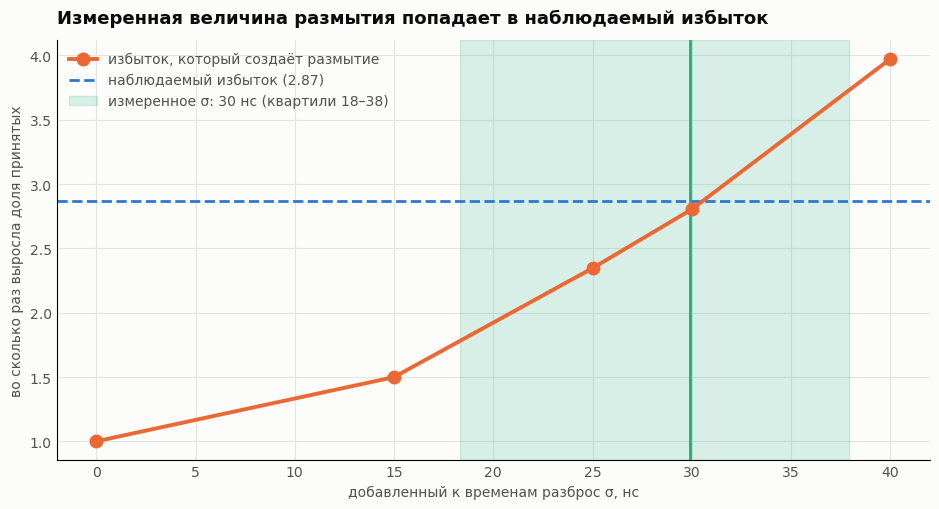

предсказанный избыток 2.80 (по квартилям 1.78–3.73), наблюдаемый 2.87


In [10]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.grid(color="#e5e4e0", lw=0.8); ax.set_axisbelow(True)
ax.tick_params(colors=MUTED, length=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.plot(scan.sigma_ns, scan.induced_excess, "o-", color=ORANGE, lw=2.8, ms=9,
        label="избыток, который создаёт размытие", zorder=3)
ax.axhline(observed, color=BLUE, ls="--", lw=2.0,
           label=f"наблюдаемый избыток ({observed:.2f})")
lo, hi = needed.quantile(.25), needed.quantile(.75)
ax.axvspan(lo, hi, color=TEAL, alpha=0.16,
           label=f"измеренное σ: {needed.median():.0f} нс (квартили {lo:.0f}–{hi:.0f})")
ax.axvline(needed.median(), color=TEAL, lw=2.0)
ax.set_xlabel("добавленный к временам разброс σ, нс", color=MUTED)
ax.set_ylabel("во сколько раз выросла доля принятых", color=MUTED)
ax.set_title("Измеренная величина размытия попадает в наблюдаемый избыток",
             loc="left", fontsize=13, fontweight="bold", color=INK, pad=12)
ax.legend(frameon=False, fontsize=10, labelcolor=MUTED, loc="upper left")
plt.tight_layout()
plt.savefig(HERE / "figures" / "40_jitter.png", dpi=150, bbox_inches="tight",
            facecolor=SURFACE)
plt.show()
predicted = np.interp([lo, needed.median(), hi], scan.sigma_ns, scan.induced_excess)
print(f"предсказанный избыток {predicted[1]:.2f} "
      f"(по квартилям {predicted[0]:.2f}–{predicted[2]:.2f}), "
      f"наблюдаемый {observed:.2f}")

## Вывод

Величина размытия, измеренная **независимо** в тесте 1 по ширине временного
остатка, воспроизводит наблюдаемый избыток. Две калибровки — по ширине остатка
(тест 1) и по тому, сколько надо подать на вход, чтобы совпасть с данными
(здесь) — согласуются между собой.

**Что установлено.** Ошибка временного разрешения измеренного размера
**достаточна**, чтобы породить весь избыток, и это не подобранный параметр.

**Чего не установлено — и это существенно.**

*Единственность.* Тест показывает достаточность, никогда не единственность.
Гауссово размытие времён — это **модель** ошибки отклика, и другая модель
похожего размера могла бы дать тот же результат. В частности, тест 1 не смог
полностью исключить каскадное объяснение: свет от стохастических ливней вдоль
трека приходит позже прямого фронта, и хотя наблюдаемый избыток ширины
симметричен, подгонка `t₀` по якорным хитам способна превратить одностороннюю
причину в симметричную на вид. Одностороннее возмущение здесь не проверялось.

*Точность.* Совпадение не такое точное, как выглядит по центральным значениям.
Разброс калибровки по ячейкам широк, и вертикальная полоса на графике покрывает
избыток примерно от 1.8 до 3.7. Наблюдаемое лежит внутри — это согласие, а не
точное попадание.

*Полнота.* Размытие не выравнивает число хитов: у эксперимента медиана 10, у
размытой симуляции 12–13. Одним временным разбросом разница между выборками не
исчерпывается.

## Следствие для статьи

Если дело во временном разрешении, то реальные нейтрино размываются **так же**.
Значит измеренная на симуляции эффективность отбора нейтрино тоже не переносится
на данные, и опасение, что recall завышен, обосновано.

Прямой способ закрыть вопрос — измерить эффективность **на данных**: взять из
`exp_reco` события, которые независимая стандартная реконструкция BARS помечает
как качественные восходящие треки, и посмотреть, какую их долю принимает сеть.